# rare/DESeq2 GSEA 비교 — 재현 러너 (thin runner)

세 GSEA 소스(no_filter / with_rare / DESeq2)의 term-level 비교, Open Targets DB 교차검증, DESeq2 커버리지를 재생성한다.
로직은 전부 `pipeline/gsea_compare.py`에 있고 이 노트북은 import+호출만 한다. DB·문헌 출처는 `GSEA/Analysis_Provenance.md` 참조.

참조 DB 자체를 다시 받으려면 먼저 `python build_disease_reference.py` (Open Targets 재조회).
정성 리포트(`GSEA/with_rare/GSEA_Master_Report.md`, `Benchmark/DESeq2_vs_Normative_Report.md`)는 아래 산출물 위에 수기 작성된 해석 문서다.

In [1]:
import sys
from pathlib import Path

parent_dir = str(Path.cwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import pandas as pd

from pipeline import gsea_compare as gc
from pipeline import plots
from viz_style import apply_style
apply_style()
pd.set_option('display.width', 200, 'display.max_columns', 20)

## 1. Term-level 겹침 통계 + 질병별 diff 리스트
`Benchmark/gsea_compare/overlap_stats.csv` + `{comparison}__{which}__{pheno}.csv`

In [2]:
stats, diffs = gc.compare_all(save=True)
for name in gc.COMPARISONS:
    s = stats[stats.comparison == name]
    print(f'== {name} (left={gc.COMPARISONS[name][0]} right={gc.COMPARISONS[name][1]}) ==')
    display(s[['phenotype','n_left','n_right','n_common','left_only','right_only','jaccard','sign_agree']]
            .reset_index(drop=True))

== rare_vs_norare (left=no_filter right=with_rare) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),961,1085,922,39,163,0.820285,1.0
1,CAD_HF- (Ward),922,984,878,44,106,0.854086,1.0
2,Colorectal Cancer (Chen),385,441,374,11,67,0.827434,1.0
3,Esophagus Cancer (Chen),683,746,638,45,108,0.806574,1.0
4,HIV (Chang),482,478,429,53,49,0.807910,1.0
5,HIV + Tuberculosis (Chang),397,434,368,29,66,0.794816,1.0
6,ICI-m (Raissadati),479,522,431,48,91,0.756140,1.0
7,ICI-treated Cancer (Raissadati),1304,1362,1226,78,136,0.851389,1.0
8,Liver Cancer (Chen),625,656,577,48,79,0.819602,1.0
9,Liver Cancer (Roskams-Hieter),217,431,206,11,225,0.466063,1.0


== deseq2_vs_norare (left=deseq2 right=no_filter) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),596,961,324,272,637,0.262774,0.981481
1,CAD_HF- (Ward),559,922,294,265,628,0.247683,0.959184
2,Colorectal Cancer (Chen),160,385,56,104,329,0.114519,1.000000
3,Esophagus Cancer (Chen),127,683,46,81,637,0.060209,0.934783
4,HIV (Chang),70,482,40,30,442,0.078125,1.000000
5,HIV + Tuberculosis (Chang),437,397,189,248,208,0.293023,0.994709
6,Liver Cancer (Chen),107,625,27,80,598,0.038298,0.481481
7,Liver Cancer (Roskams-Hieter),287,217,50,237,167,0.110132,0.980000
8,Lung Cancer (Chen),319,520,181,138,339,0.275076,1.000000
9,ME_CFS (Gardella),98,169,8,90,161,0.030888,1.000000


== deseq2_vs_withrare (left=deseq2 right=with_rare) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),596,1085,340,256,745,0.253542,0.979412
1,CAD_HF- (Ward),559,984,308,251,676,0.249393,0.954545
2,Colorectal Cancer (Chen),160,441,59,101,382,0.108856,1.000000
3,Esophagus Cancer (Chen),127,746,48,79,698,0.058182,0.937500
4,HIV (Chang),70,478,42,28,436,0.083004,1.000000
5,HIV + Tuberculosis (Chang),437,434,215,222,219,0.327744,0.995349
6,Liver Cancer (Chen),107,656,27,80,629,0.036685,0.518519
7,Liver Cancer (Roskams-Hieter),287,431,67,220,364,0.102919,0.985075
8,Lung Cancer (Chen),319,548,186,133,362,0.273128,1.000000
9,ME_CFS (Gardella),98,226,9,89,217,0.028571,1.000000


## 2. 신규(with_rare) 신호의 DB/rare 교차검증
`rare_novel_validated.csv` (term 단위) + `rare_novel_summary.csv` (질병 단위)

In [3]:
long, summary = gc.validate_rare_novel(diffs, save=True)
display(summary[['phenotype','n_new_terms','n_db_supported','n_rare_driven','n_db_and_rare','frac_db_supported']])
print('rare 유전자가 직접 lead한 신규 term (직접 근거):')
display(long[long.rare_driven][['phenotype','Term','NES','n_db','db_hits','rare_hits']]
        .sort_values('phenotype').reset_index(drop=True))

/project/cfRNA_NormativeModeling/Modeling/pipeline/gsea_compare.py:277: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'n_db_and_rare': g.apply(lambda x: (x['db_supported'] & x['rare_driven']).sum()),


,phenotype,n_new_terms,n_db_supported,n_rare_driven,n_db_and_rare,frac_db_supported
9,Liver Cancer (Roskams-Hieter),225,162,4,4,0.720
0,CAD_HF+ (Ward),163,51,0,0,0.313
7,ICI-treated Cancer (Raissadati),136,0,0,0,0.000
3,Esophagus Cancer (Chen),108,41,4,2,0.380
1,CAD_HF- (Ward),106,30,0,0,0.283
19,Tuberculosis (Chang),104,60,1,0,0.577
13,MM (Roskams-Hieter),92,58,1,1,0.630
6,ICI-m (Raissadati),91,40,2,0,0.440
15,Pancreatic Cancer (Moore),90,43,4,2,0.478
8,Liver Cancer (Chen),79,31,0,0,0.392


rare 유전자가 직접 lead한 신규 term (직접 근거):


,phenotype,Term,NES,n_db,db_hits,rare_hits
0,Esophagus Cancer (Chen),GO_Biological_Process_2023__Extracellular Matr...,2.168206,2,CREB3L1;NF1,MMP3
1,Esophagus Cancer (Chen),KEGG_2021_Human__cAMP signaling pathway,2.080110,8,AKT1;BRAF;CACNA1D;CREB3L1;CREBBP;GRIN2A;PIK3R1...,PDE4C;TSHB
2,Esophagus Cancer (Chen),GO_Biological_Process_2023__Detection Of Chemi...,1.968650,0,,OR10H3;OR13C8
3,Esophagus Cancer (Chen),GO_Biological_Process_2023__Detection Of Chemi...,1.939821,0,,OR10H3;OR13C8
4,ICI-m (Raissadati),Reactome_2022__Iron Uptake And Transport R-HSA...,1.802655,0,,ATP6V1G3
5,ICI-m (Raissadati),GO_Biological_Process_2023__Response To Zinc I...,1.718359,0,,MT1B
6,Liver Cancer (Roskams-Hieter),GO_Biological_Process_2023__Negative Regulatio...,1.752901,3,APOE;NF1;SH2B3,DEFB114
7,Liver Cancer (Roskams-Hieter),GO_Biological_Process_2023__Negative Regulatio...,1.732848,3,APOE;NF1;SH2B3,DEFB114
8,Liver Cancer (Roskams-Hieter),GO_Biological_Process_2023__Regulation Of MAP ...,1.685643,9,APOE;EGFR;FGF1;FGF2;FLT1;NF1;NTRK3;SH2B3;SOS1,DEFB114
9,Liver Cancer (Roskams-Hieter),GO_Biological_Process_2023__Androgen Receptor ...,1.664844,2,ARID1A;MAPK1,CST11


## 3. DESeq2의 normative DB-지지 경로 커버리지
`deseq2_coverage.csv` — 포착률·방향불일치율

In [4]:
cov = gc.deseq2_coverage(save=True)
wr = cov[cov.normative == 'with_rare'].drop(columns='normative')
display(wr[['phenotype','n_deseq2_sig','n_norm_sig','n_norm_db','n_db_captured','db_capture_rate','n_common','sign_disagree_rate']]
        .sort_values('db_capture_rate').reset_index(drop=True))
print('DB-지지 경로 포착률 중앙값: with_rare=%.3f  no_filter=%.3f'
      % (wr.db_capture_rate.median(), cov[cov.normative=='no_filter'].db_capture_rate.median()))

,phenotype,n_deseq2_sig,n_norm_sig,n_norm_db,n_db_captured,db_capture_rate,n_common,sign_disagree_rate
0,Pre-eclampsia (Moufarrej),54,282,41,0,0.000,13,0.000
1,Liver Cancer (Chen),107,656,320,5,0.016,27,0.481
2,Pancreatic Cancer (Moore),130,604,297,9,0.030,57,0.702
3,ME_CFS (Gardella),98,226,142,6,0.042,9,0.000
4,Esophagus Cancer (Chen),127,746,290,16,0.055,48,0.062
5,Colorectal Cancer (Chen),160,441,186,12,0.065,59,0.000
6,Pancreatitis (Moore),50,310,119,8,0.067,22,0.955
7,MGUS (Roskams-Hieter),188,127,13,1,0.077,16,0.062
8,HIV (Chang),70,478,254,37,0.146,42,0.000
9,Liver Cancer (Roskams-Hieter),287,431,314,52,0.166,67,0.015


DB-지지 경로 포착률 중앙값: with_rare=0.156  no_filter=0.178


## 4. 대칭 DB-hit 비교 (DESeq2 vs Normative)
섹션 3의 `deseq2_coverage`는 DB-지지를 normative 항목에서만 정의한 뒤 DESeq2 포착률을 보는 비대칭 관점이다. 여기서는 세 방법(deseq2 / no_filter / with_rare)을 **동일 규칙**(자기 유의 term의 lead gene ∩ Open Targets 참조)으로 채점해 DB-hit **개수**와 비율을 대칭적으로 비교한다. 개수(절대 커버리지)가 비율(정밀도)보다 중요할 수 있으므로 둘 다 표시한다.
`Benchmark/gsea_compare/db_hit_rates.csv` + `_summary.csv`, `Benchmark/Figures/db_hit_rates.png`

== pooled over phenotypes with an Open Targets reference ==


,method,n_pheno,total_sig,total_db,mean_db_hit_rate,pooled_db_hit_rate
0,deseq2,18,4566,2220,0.453,0.486
1,deseq2_cov,18,1963,1143,0.437,0.582
2,no_filter,19,8721,3825,0.446,0.439
3,with_rare,19,9837,4375,0.450,0.445



== per-phenotype DB-hit counts (n_db) ==


method,deseq2,deseq2_cov,no_filter,with_rare
phenotype,,,,
CAD_HF+ (Ward),183.0,1.0,252.0,291.0
CAD_HF- (Ward),167.0,1.0,247.0,264.0
Colorectal Cancer (Chen),95.0,14.0,157.0,186.0
Esophagus Cancer (Chen),77.0,3.0,274.0,290.0
HIV (Chang),51.0,54.0,263.0,254.0
HIV + Tuberculosis (Chang),322.0,178.0,233.0,266.0
ICI-m (Raissadati),NaN,NaN,247.0,267.0
Liver Cancer (Chen),52.0,38.0,306.0,320.0
Liver Cancer (Roskams-Hieter),194.0,24.0,157.0,314.0


== per-phenotype DB-hit rate (n_db / n_sig) ==


method,deseq2,deseq2_cov,no_filter,with_rare
phenotype,,,,
CAD_HF+ (Ward),0.307,0.091,0.262,0.268
CAD_HF- (Ward),0.299,0.500,0.268,0.268
Colorectal Cancer (Chen),0.594,0.700,0.408,0.422
Esophagus Cancer (Chen),0.606,0.600,0.401,0.389
HIV (Chang),0.729,0.486,0.546,0.531
HIV + Tuberculosis (Chang),0.737,0.616,0.587,0.613
ICI-m (Raissadati),NaN,NaN,0.516,0.511
Liver Cancer (Chen),0.486,0.623,0.490,0.488
Liver Cancer (Roskams-Hieter),0.676,0.324,0.724,0.729


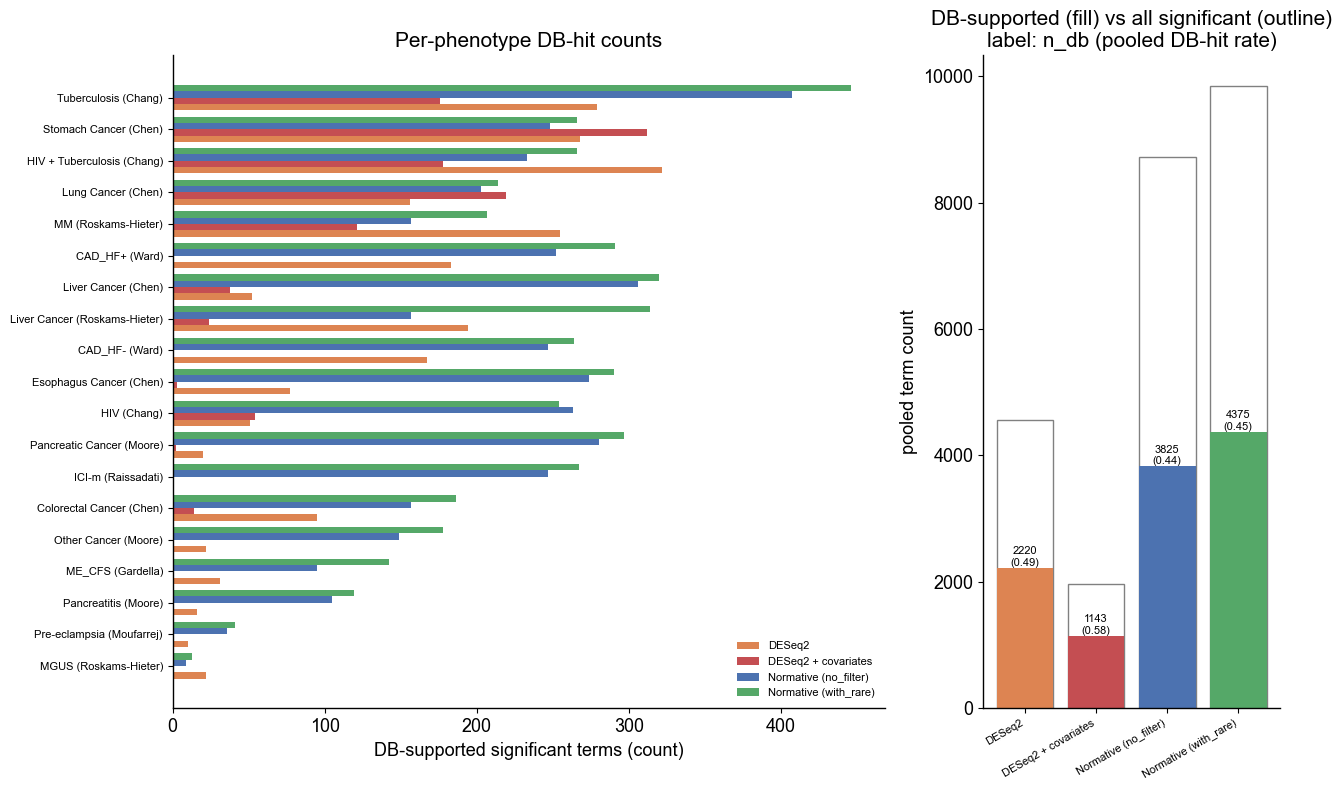

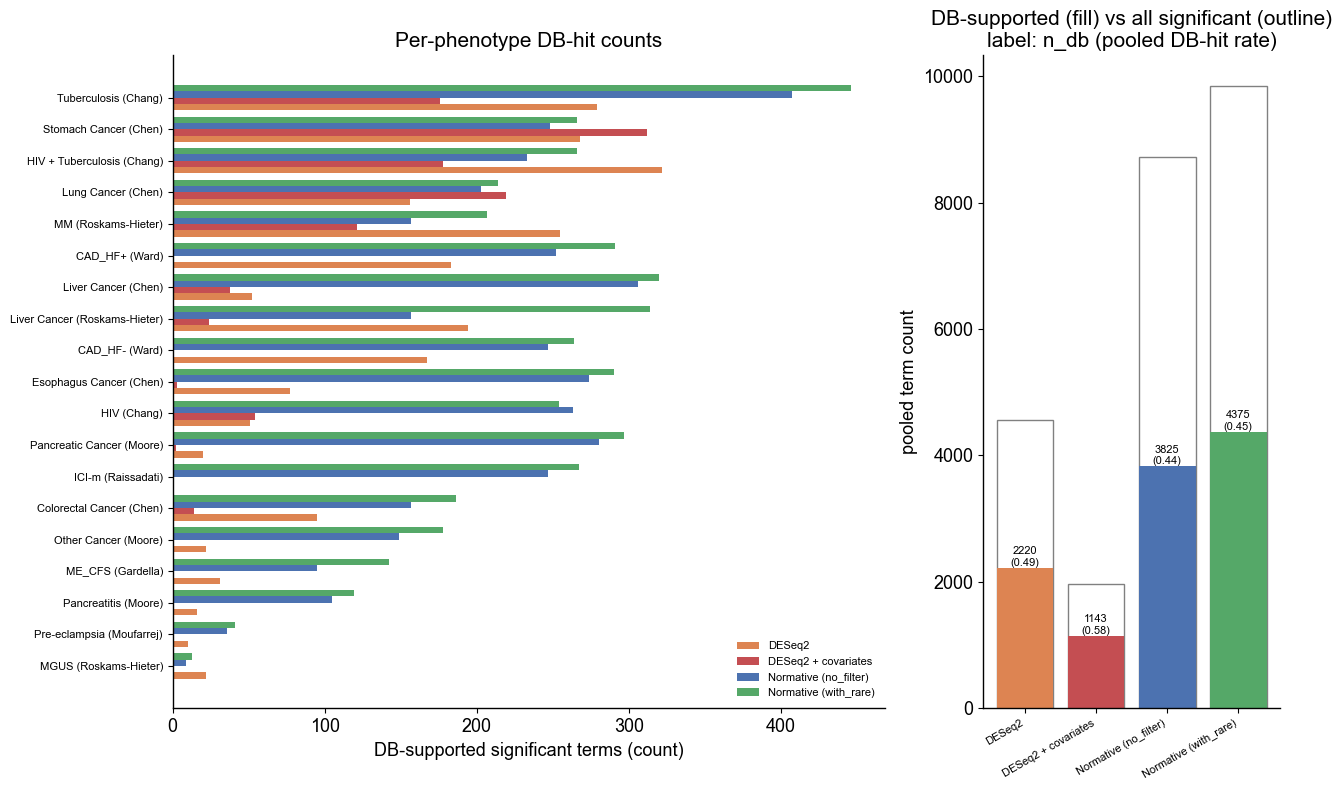

In [5]:
rates, db_summary = gc.db_hit_rates(save=True)
print('== pooled over phenotypes with an Open Targets reference ==')
display(db_summary)
methods_avail = [m for m in ['deseq2', 'deseq2_cov', 'no_filter', 'with_rare']
                 if m in rates['method'].unique()]
sub = rates[rates.has_ot_ref]
print('\n== per-phenotype DB-hit counts (n_db) ==')
display(sub.pivot(index='phenotype', columns='method', values='n_db')[methods_avail])
print('== per-phenotype DB-hit rate (n_db / n_sig) ==')
display(sub.pivot(index='phenotype', columns='method', values='db_hit_rate')[methods_avail])
plots.plot_db_hit_rates(rates, db_summary, save=True)

## 5. DESeq2 공변량 보정 vs 미보정 GSEA 비교
`run_deseq2_covariate.py` 산출물 (`Benchmark/deseq2_covariate_gsea/`): 10개 BIAS_COLUMNS를 전체 샘플 StandardScaler로 표준화한 뒤 design `~cov1+...+cov10+condition`으로 보정한 버전.
- `deseq2_cov_vs_nocov_overlap.csv`: term-level Jaccard + sign_agree (공변량 보정 전후 변화 정도)
- `deseq2_cov_db_hits.csv`: deseq2_cov만의 단독 DB-hit (섹션 4 요약에는 이미 통합됨)

In [6]:
ov_cov, db_cov = gc.deseq2_cov_vs_nocov(save=True)
print('== DESeq2 공변량 보정 전후 term-level 겹침 ==')
display(ov_cov[['phenotype','n_left','n_right','n_common','left_only','right_only','jaccard','sign_agree']]
        .sort_values('jaccard').reset_index(drop=True))
print('\nJaccard 중앙값:', round(ov_cov.jaccard.median(), 3),
      '  sign_agree 중앙값:', round(ov_cov.sign_agree.median(), 3))
print('\n== deseq2_cov DB-hit (per phenotype) ==')
display(db_cov[['phenotype','n_sig','n_db','db_hit_rate']].sort_values('n_db', ascending=False).reset_index(drop=True))

== DESeq2 공변량 보정 전후 term-level 겹침 ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF- (Ward),559,2,0,559,2,0.000000,NaN
1,Pancreatitis (Moore),50,0,0,50,0,0.000000,NaN
2,MGUS (Roskams-Hieter),188,0,0,188,0,0.000000,NaN
3,ME_CFS (Gardella),98,1,0,98,1,0.000000,NaN
4,Other Cancer (Moore),72,0,0,72,0,0.000000,NaN
5,Esophagus Cancer (Chen),127,5,1,126,4,0.007634,1.000000
6,CAD_HF+ (Ward),596,11,9,587,2,0.015050,0.111111
7,Pre-eclampsia (Moufarrej),54,2,1,53,1,0.018182,1.000000
8,Colorectal Cancer (Chen),160,20,7,153,13,0.040462,1.000000
9,Liver Cancer (Chen),107,61,10,97,51,0.063291,1.000000



Jaccard 중앙값: 0.052   sign_agree 중앙값: 1.0

== deseq2_cov DB-hit (per phenotype) ==


,phenotype,n_sig,n_db,db_hit_rate
0,Stomach Cancer (Chen),541,312,0.577
1,Lung Cancer (Chen),388,219,0.564
2,HIV + Tuberculosis (Chang),289,178,0.616
3,Tuberculosis (Chang),209,176,0.842
4,MM (Roskams-Hieter),228,121,0.531
5,HIV (Chang),111,54,0.486
6,Liver Cancer (Chen),61,38,0.623
7,Liver Cancer (Roskams-Hieter),74,24,0.324
8,Colorectal Cancer (Chen),20,14,0.700
9,Esophagus Cancer (Chen),5,3,0.600
